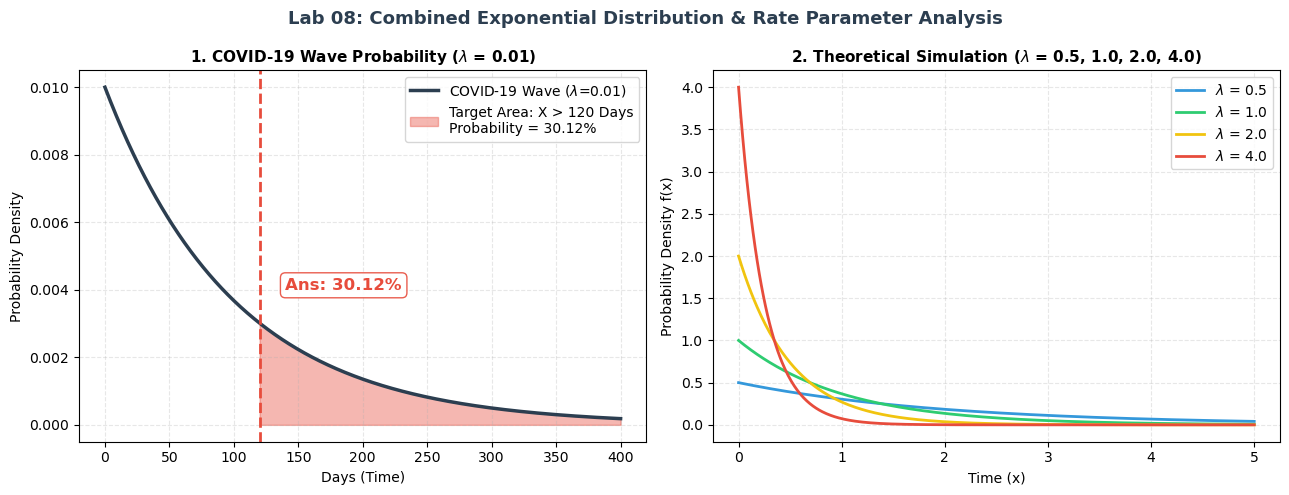

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- ১. কভিড-১৯ ম্যাথমেটিক্যাল ডেটা সেটআপ ---
mean_days = 100
lam_covid = 1 / mean_days  # lambda = 0.01
target_days = 120
prob_ans = np.exp(-lam_covid * target_days) # উত্তর: ৩০.১২%

# --- ২. কম্বাইন্ড গ্রাফ তৈরি (১টি ইমেজে সবগুলো ল্যাম্বডা) ---
# plt.figure() ব্যবহার না করে সরাসরি সাবপ্লট ডিফাইন করা হয়েছে
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (ক) বাম পাশের গ্রাফ: কভিড-১৯ এর জন্য ল্যাম্বডা = 0.01
x_covid = np.linspace(0, 400, 1000)
y_covid = lam_covid * np.exp(-lam_covid * x_covid)
ax1.plot(x_covid, y_covid, color='#2c3e50', linewidth=2.5, label=f'COVID-19 Wave ($\lambda$={lam_covid})')

# ১২০ দিনের বেশি এলাকা রঙ (Shade) করা
x_shaded = np.linspace(target_days, 400, 500)
y_shaded = lam_covid * np.exp(-lam_covid * x_shaded)
ax1.fill_between(x_shaded, y_shaded, color='#e74c3c', alpha=0.4, 
                 label=f'Target Area: X > 120 Days\nProbability = {prob_ans*100:.2f}%')
ax1.axvline(x=target_days, color='#e74c3c', linestyle='--', linewidth=2)

# গ্রাফের ভেতরেই বড় করে উত্তর লিখে দেওয়া
ax1.text(140, 0.004, f"Ans: {prob_ans*100:.2f}%", color='#e74c3c', fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.3', edgecolor='#e74c3c'))

ax1.set_title("1. COVID-19 Wave Probability ($\lambda$ = 0.01)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Days (Time)")
ax1.set_ylabel("Probability Density")
ax1.legend(loc='upper right')
ax1.grid(True, linestyle="--", alpha=0.3)

# (খ) ডান পাশের গ্রাফ: বাকি ৪টি ল্যাম্বডার সিমুলেশন (0.5, 1.0, 2.0, 4.0)
x_sim = np.linspace(0, 5, 500)
rates = [0.5, 1.0, 2.0, 4.0]
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e74c3c']

for r, color in zip(rates, colors):
    y_sim = r * np.exp(-r * x_sim)
    ax2.plot(x_sim, y_sim, label=f'$\lambda$ = {r}', color=color, linewidth=2)

ax2.set_title("2. Theoretical Simulation ($\lambda$ = 0.5, 1.0, 2.0, 4.0)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Time (x)")
ax2.set_ylabel("Probability Density f(x)")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle="--", alpha=0.3)

# ওভারঅল টাইটেল সেটআপ
plt.suptitle("Lab 08: Combined Exponential Distribution & Rate Parameter Analysis", fontsize=13, fontweight='bold', color='#2c3e50', y=0.98)
plt.tight_layout()

# ইমেজ ফাইল হিসেবে সেভ করা
plt.savefig('combined_exponential_analysis.png', dpi=300)